In [2]:
import numpy as np
import matplotlib.pyplot as plt
from environment import MazeEnv
import os
%matplotlib inline

# Create results directory
os.makedirs('results', exist_ok=True)

In [3]:
def state_index(state, mx):
    return state[0] + mx * state[1]

def train_q_learning(env, mx, my, alpha=0.3, gamma=0.9, epsilon=0.2, epochs=500, verbose=False):
    """Train Q-Learning algorithm on maze environment"""
    Q = np.random.rand(mx * my, 4)  # dimensions: states, actions
    history = []
    heatmap = np.zeros((mx, my))
    
    for epoch in range(epochs):    
        state = env.reset()
        done = False
        
        while not done:
            heatmap[state] += 1
            
            if np.random.rand() <= epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(Q[state_index(state, mx)])

            new_state, reward, done, info = env.step(action)
            Q[state_index(state, mx), action] += alpha * (reward + gamma * np.max(Q[state_index(new_state, mx)]) - Q[state_index(state, mx), action])
            state = new_state
            
        history.append(info['time'])
        if verbose and (epoch % 100 == 0):
            print(f'Epoch {epoch}: Finished in {info["time"]} steps')
    
    return Q, history, heatmap

In [4]:
def test_route(env, Q, mx, epsilon=0, start_pos=None, max_steps=10000, verbose=True):
    """Test a single route using trained Q-table"""
    if start_pos is not None:
        env.reset()
        env.player = list(start_pos)
        env.trajectory_x = [start_pos[0]]
        env.trajectory_y = [start_pos[1]]
        state = start_pos
    else:
        state = env.reset()
    
    done = False
    steps = 0
    
    while not done and steps < max_steps:
        steps += 1
        
        if np.random.rand() <= epsilon:
            action = np.random.randint(4)
        else:
            action = np.argmax(Q[state_index(state, mx)])

        new_state, reward, done, info = env.step(action)
        state = new_state
    
    if verbose:
        if done:
            print(f'✓ Route found in {info["time"]} steps')
        else:
            print(f'✗ No route found (stopped after {max_steps} steps)')
    
    return done, info

In [5]:
def plot_maze_with_arrows(env, Q, mx, my, arrow_type='best', title='', save_path=None):
    """Plot maze with Q-value arrows"""
    plt.figure(figsize=(max(8, mx*0.3), max(6, my*0.3)))
    env.reset()
    env.render()
    
    if arrow_type == 'all':
        # Plot arrows for each direction, where the arrow width represents the Q value
        arrow_length = 0.2
        c = 'k'
        width_factor = 0.001 / np.max(Q) if np.max(Q) > 0 else 0.001
        for x in range(mx):
            for y in range(my):
                plt.arrow(x, y, 0., arrow_length, ec=c, fc=c, width=width_factor*Q[state_index((x, y), mx), 0])  # up
                plt.arrow(x, y, 0., -arrow_length, ec=c, fc=c, width=width_factor*Q[state_index((x, y), mx), 1])  # down
                plt.arrow(x, y, -arrow_length, 0., ec=c, fc=c, width=width_factor*Q[state_index((x, y), mx), 2])  # left
                plt.arrow(x, y, arrow_length, 0., ec=c, fc=c, width=width_factor*Q[state_index((x, y), mx), 3])  # right
    else:  # 'best'
        # Plot arrow for the direction with the highest Q value
        l = 0.3
        c = 'k'
        w = max(0.01, 0.3/mx)  # Adjust arrow width based on maze size
        for x in range(mx):
            for y in range(my):
                best_action = np.argmax(Q[state_index((x, y), mx)])
                if best_action == 0:            
                    plt.arrow(x, y-0.5*l, 0, l, ec=c, fc=c, width=w, head_width=3*w)  # up
                elif best_action == 1:
                    plt.arrow(x, y+0.5*l, 0., -l, ec=c, fc=c, width=w, head_width=3*w)  # down
                elif best_action == 2:
                    plt.arrow(x+0.5*l, y, -l, 0., ec=c, fc=c, width=w, head_width=3*w)  # left
                elif best_action == 3:
                    plt.arrow(x-0.5*l, y, l, 0., ec=c, fc=c, width=w, head_width=3*w)  # right
    
    plt.title(title, fontsize=12)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

def plot_route(env, title='', save_path=None):
    """Plot the final route taken"""
    plt.figure(figsize=(max(8, env.mx*0.3), max(6, env.my*0.3)))
    env.render()
    plt.title(title, fontsize=12)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

In [6]:
def run_experiment(mx, my, epsilon, gamma, epochs=500, experiment_name=''):
    """Run a complete experiment with given parameters"""
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Maze size: {mx}x{my}, epsilon: {epsilon}, gamma: {gamma}, epochs: {epochs}")
    print(f"{'='*80}\n")
    
    # Create environment
    env = MazeEnv(mx, my)
    env.reset()
    print(f"Treasure position: {env.treasure}")
    
    # Train Q-Learning
    print("\nTraining...")
    Q, history, heatmap = train_q_learning(env, mx, my, alpha=0.3, gamma=gamma, epsilon=epsilon, epochs=epochs, verbose=True)
    print(f"Training complete!\n")
    
    # Plot training history
    plt.figure(figsize=(10, 4))
    plt.plot(history)
    plt.xlabel('Epoch')
    plt.ylabel('Time steps to solve maze')
    plt.title(f'Training History - {experiment_name}')
    plt.grid(True, alpha=0.3)
    save_path = f'results/{experiment_name.replace(" ", "_")}_history.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    
    # Plot Q-value arrows (best actions)
    plot_maze_with_arrows(env, Q, mx, my, arrow_type='best', 
                         title=f'Best Actions (Q-values) - {experiment_name}',
                         save_path=f'results/{experiment_name.replace(" ", "_")}_arrows.png')
    
    # Test route from start (0, 0)
    print("\n--- Route from start (0, 0) to treasure ---")
    success, info = test_route(env, Q, mx, epsilon=0, start_pos=None)
    if success:
        plot_route(env, title=f'Route from (0,0) - {experiment_name}',
                  save_path=f'results/{experiment_name.replace(" ", "_")}_route_start.png')
    
    # Test route from alternative starting points
    alternative_starts = [
        (mx//2, my//2),  # Center
        (mx-1, 0),       # Bottom right
        (0, my-1)        # Top left
    ]
    
    for i, start_pos in enumerate(alternative_starts):
        # Check if start position is valid (not a wall)
        if env.maze[start_pos] == 0:
            print(f"\n--- Route from alternative start {start_pos} to treasure ---")
            success, info = test_route(env, Q, mx, epsilon=0, start_pos=start_pos)
            if success:
                plot_route(env, title=f'Route from {start_pos} - {experiment_name}',
                          save_path=f'results/{experiment_name.replace(" ", "_")}_route_alt{i+1}.png')
    
    return env, Q, history

## Experiments for 20x10 Maze


EXPERIMENT: 20x10_eps0.0_gamma0.9
Maze size: 20x10, epsilon: 0.0, gamma: 0.9, epochs: 500

Treasure position: (0, 7)

Training...
Epoch 0: Finished in 17467 steps
Epoch 100: Finished in 39 steps
Epoch 200: Finished in 39 steps
Epoch 300: Finished in 39 steps
Epoch 400: Finished in 39 steps
Training complete!



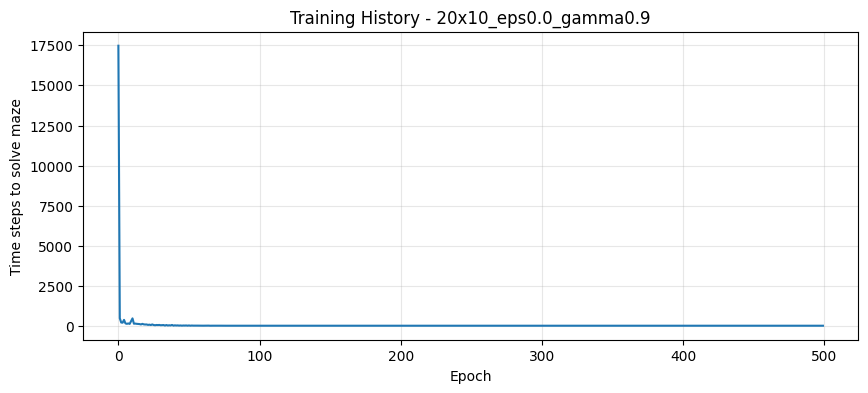

<Figure size 800x600 with 0 Axes>

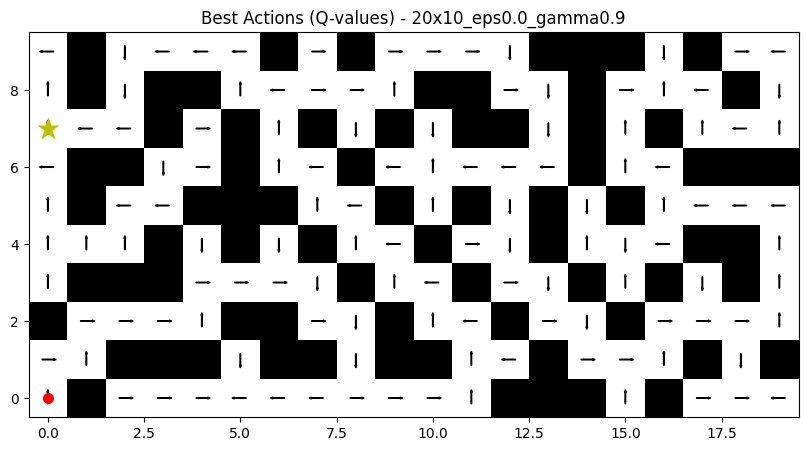


--- Route from start (0, 0) to treasure ---
✓ Route found in 39 steps


<Figure size 800x600 with 0 Axes>

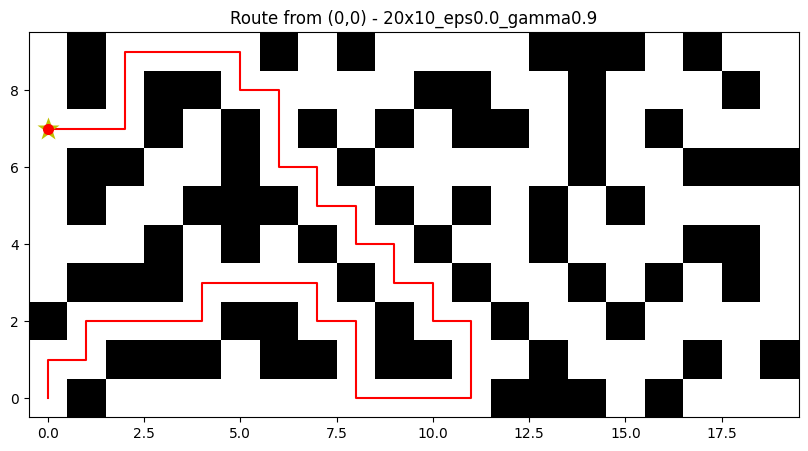


--- Route from alternative start (10, 5) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (19, 0) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (0, 9) to treasure ---
✗ No route found (stopped after 10000 steps)


In [7]:
# 20x10 maze with epsilon=0, gamma=0.9
env1, Q1, hist1 = run_experiment(20, 10, epsilon=0.0, gamma=0.9, epochs=500, experiment_name='20x10_eps0.0_gamma0.9')


EXPERIMENT: 20x10_eps0.0_gamma0.95
Maze size: 20x10, epsilon: 0.0, gamma: 0.95, epochs: 500

Treasure position: (0, 2)

Training...
Epoch 0: Finished in 125619 steps
Epoch 100: Finished in 22 steps
Epoch 200: Finished in 22 steps
Epoch 300: Finished in 22 steps
Epoch 400: Finished in 22 steps
Training complete!



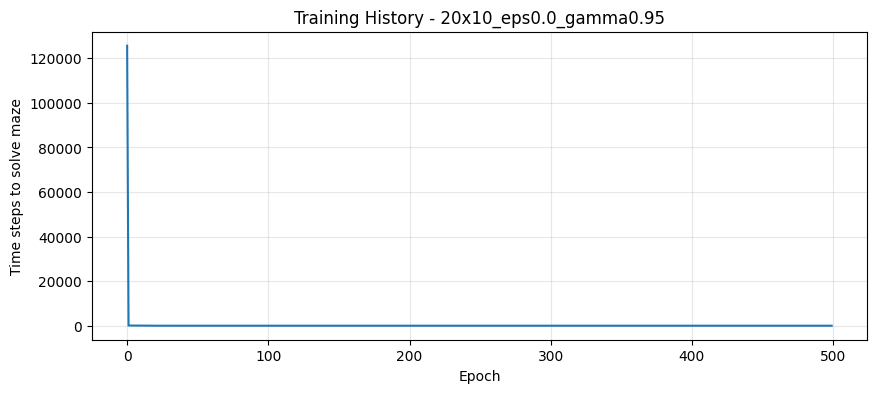

<Figure size 800x600 with 0 Axes>

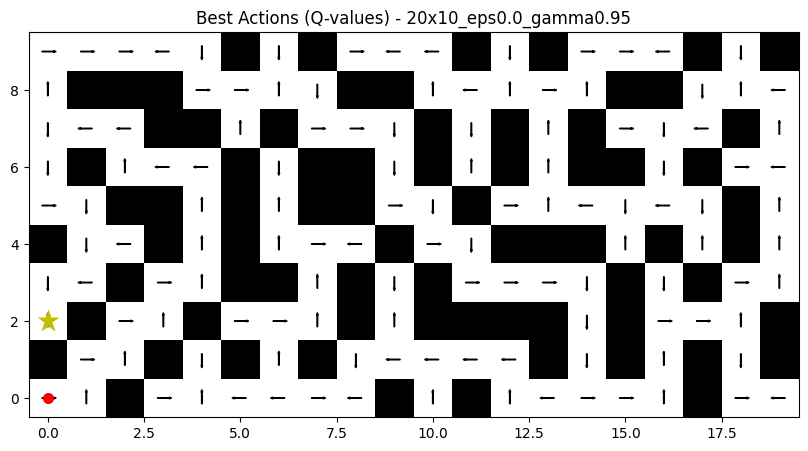


--- Route from start (0, 0) to treasure ---
✓ Route found in 22 steps


<Figure size 800x600 with 0 Axes>

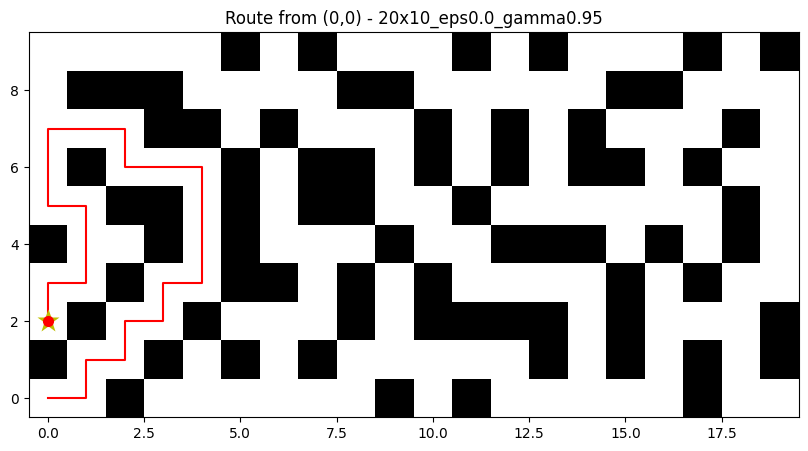


--- Route from alternative start (10, 5) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (19, 0) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (0, 9) to treasure ---
✗ No route found (stopped after 10000 steps)


In [8]:
# 20x10 maze with epsilon=0, gamma=0.95
env2, Q2, hist2 = run_experiment(20, 10, epsilon=0.0, gamma=0.95, epochs=500, experiment_name='20x10_eps0.0_gamma0.95')


EXPERIMENT: 20x10_eps0.1_gamma0.9
Maze size: 20x10, epsilon: 0.1, gamma: 0.9, epochs: 500

Treasure position: (9, 8)

Training...
Epoch 0: Finished in 10048 steps
Epoch 100: Finished in 68 steps
Epoch 200: Finished in 51 steps
Epoch 300: Finished in 65 steps
Epoch 400: Finished in 55 steps
Training complete!



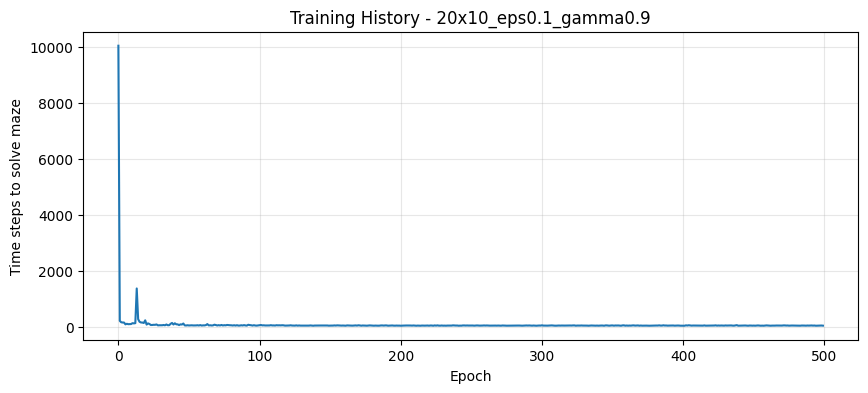

<Figure size 800x600 with 0 Axes>

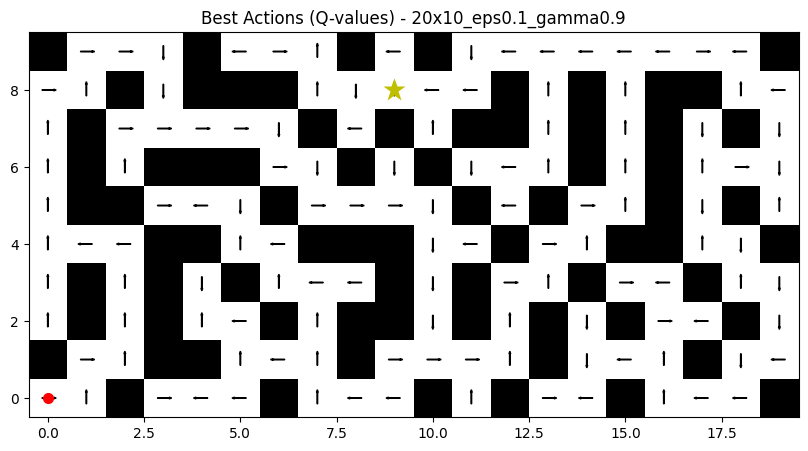


--- Route from start (0, 0) to treasure ---
✓ Route found in 51 steps


<Figure size 800x600 with 0 Axes>

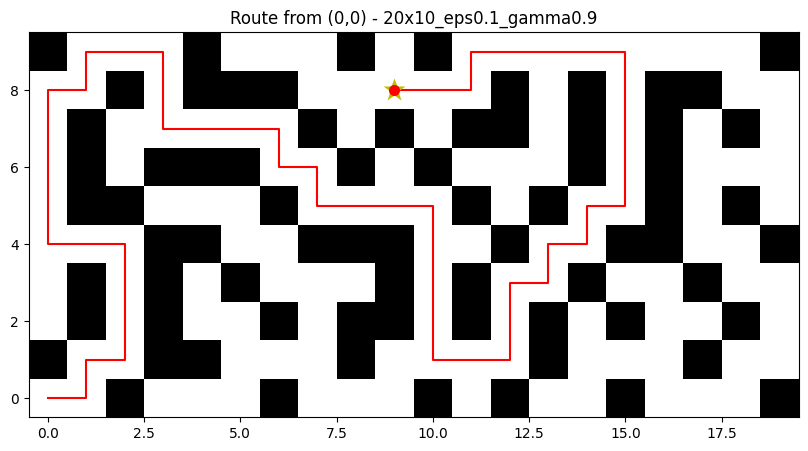


--- Route from alternative start (10, 5) to treasure ---
✓ Route found in 24 steps


<Figure size 800x600 with 0 Axes>

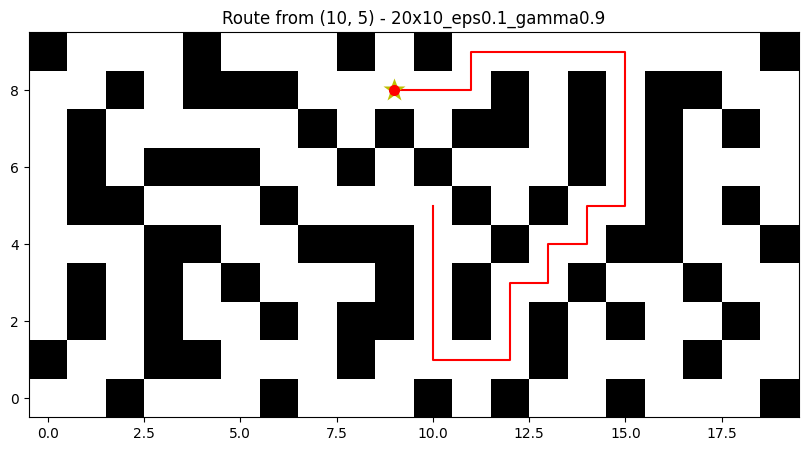

In [9]:
# 20x10 maze with epsilon=0.1, gamma=0.9
env3, Q3, hist3 = run_experiment(20, 10, epsilon=0.1, gamma=0.9, epochs=500, experiment_name='20x10_eps0.1_gamma0.9')


EXPERIMENT: 20x10_eps0.1_gamma0.95
Maze size: 20x10, epsilon: 0.1, gamma: 0.95, epochs: 500

Treasure position: (2, 8)

Training...
Epoch 0: Finished in 4881 steps
Epoch 100: Finished in 24 steps
Epoch 200: Finished in 29 steps
Epoch 300: Finished in 25 steps
Epoch 400: Finished in 25 steps
Training complete!



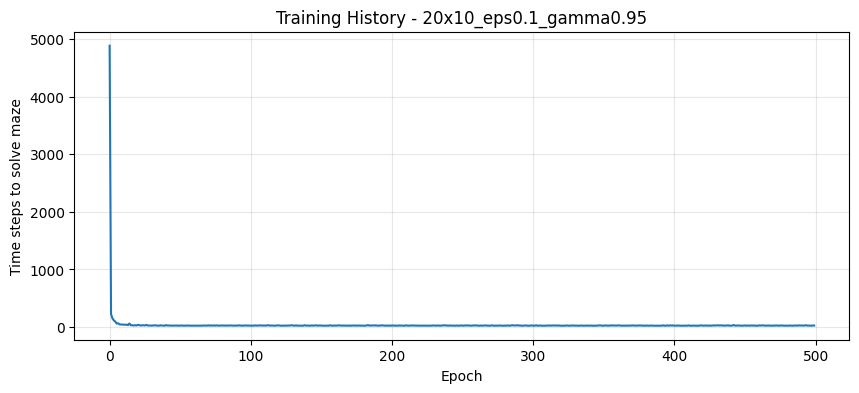

<Figure size 800x600 with 0 Axes>

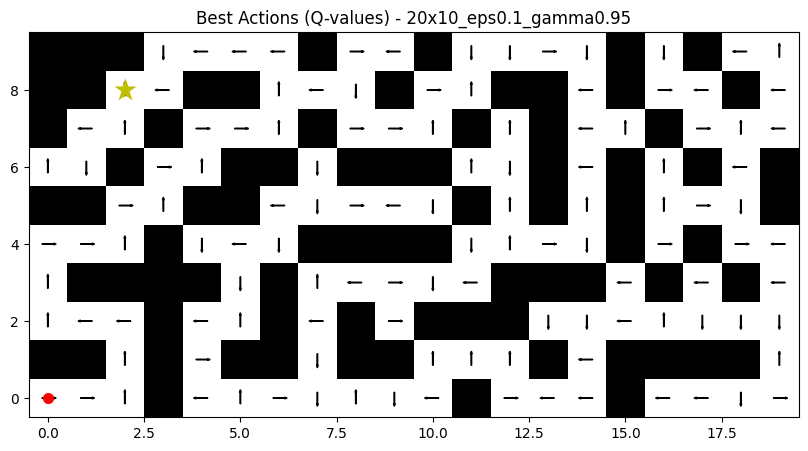


--- Route from start (0, 0) to treasure ---
✓ Route found in 24 steps


<Figure size 800x600 with 0 Axes>

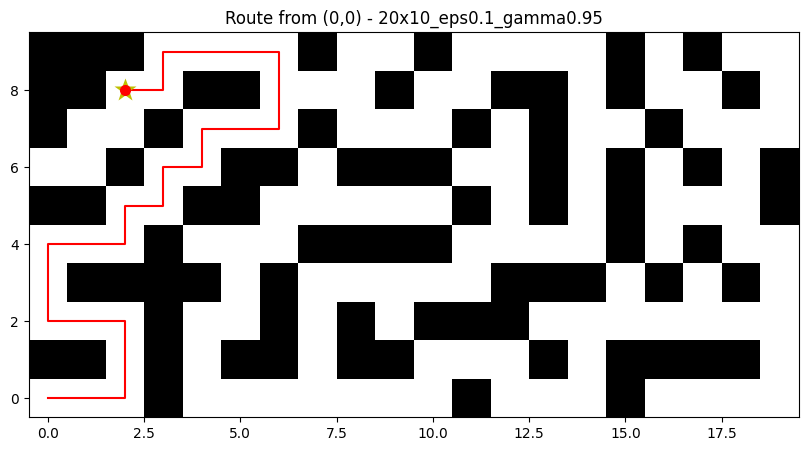


--- Route from alternative start (10, 5) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (19, 0) to treasure ---
✗ No route found (stopped after 10000 steps)


In [10]:
# 20x10 maze with epsilon=0.1, gamma=0.95
env4, Q4, hist4 = run_experiment(20, 10, epsilon=0.1, gamma=0.95, epochs=500, experiment_name='20x10_eps0.1_gamma0.95')


EXPERIMENT: 20x10_eps0.2_gamma0.9
Maze size: 20x10, epsilon: 0.2, gamma: 0.9, epochs: 500

Treasure position: (10, 5)

Training...
Epoch 0: Finished in 3766 steps
Epoch 100: Finished in 56 steps
Epoch 200: Finished in 61 steps
Epoch 300: Finished in 54 steps
Epoch 400: Finished in 56 steps
Training complete!



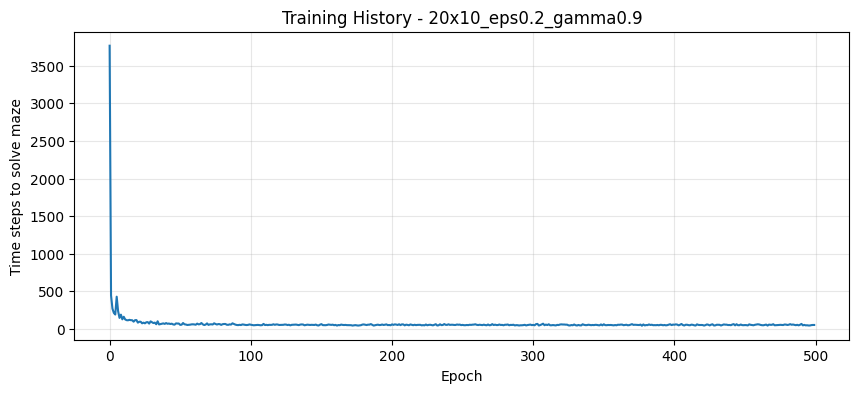

<Figure size 800x600 with 0 Axes>

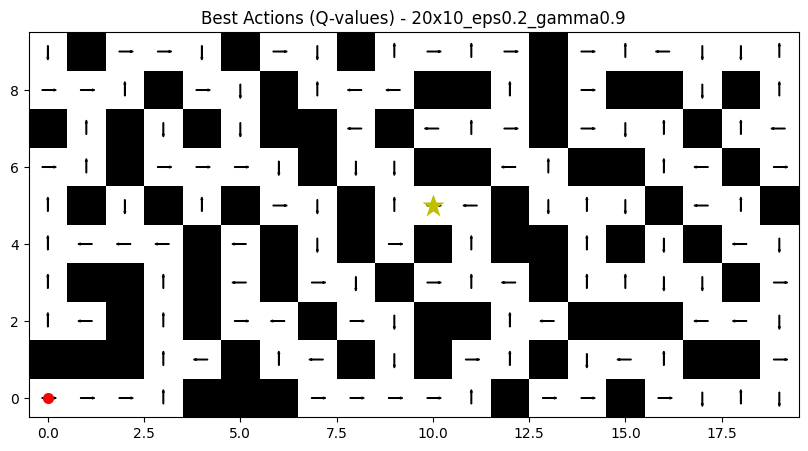


--- Route from start (0, 0) to treasure ---
✓ Route found in 43 steps


<Figure size 800x600 with 0 Axes>

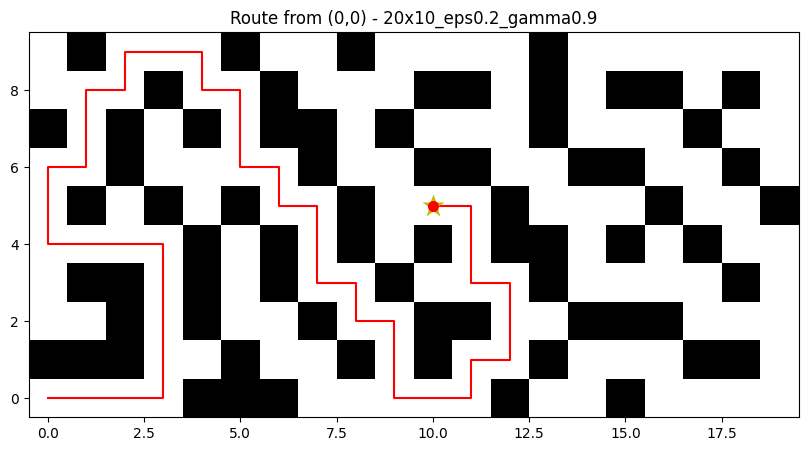


--- Route from alternative start (10, 5) to treasure ---
✓ Route found in 2 steps


<Figure size 800x600 with 0 Axes>

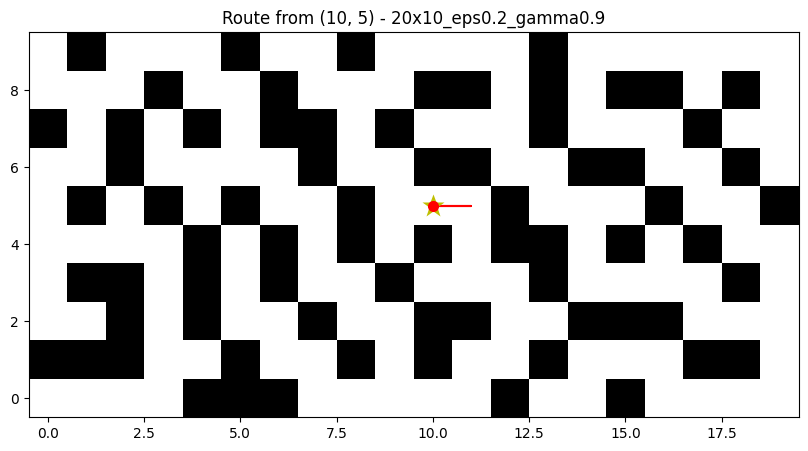


--- Route from alternative start (19, 0) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (0, 9) to treasure ---
✓ Route found in 30 steps


<Figure size 800x600 with 0 Axes>

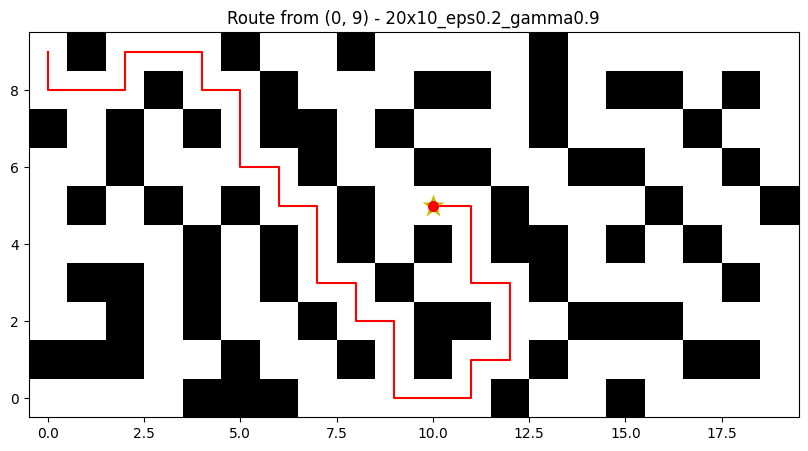

In [11]:
# 20x10 maze with epsilon=0.2, gamma=0.9
env5, Q5, hist5 = run_experiment(20, 10, epsilon=0.2, gamma=0.9, epochs=500, experiment_name='20x10_eps0.2_gamma0.9')


EXPERIMENT: 20x10_eps0.2_gamma0.95
Maze size: 20x10, epsilon: 0.2, gamma: 0.95, epochs: 500

Treasure position: (5, 0)

Training...
Epoch 0: Finished in 4887 steps
Epoch 100: Finished in 66 steps
Epoch 200: Finished in 66 steps
Epoch 300: Finished in 67 steps
Epoch 400: Finished in 66 steps
Training complete!



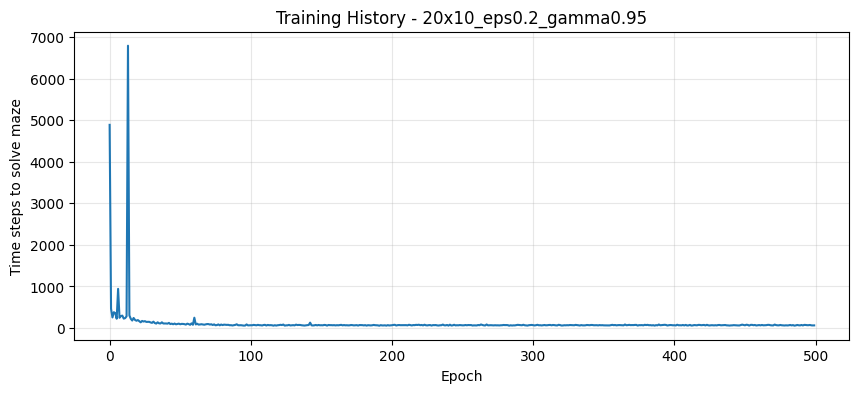

<Figure size 800x600 with 0 Axes>

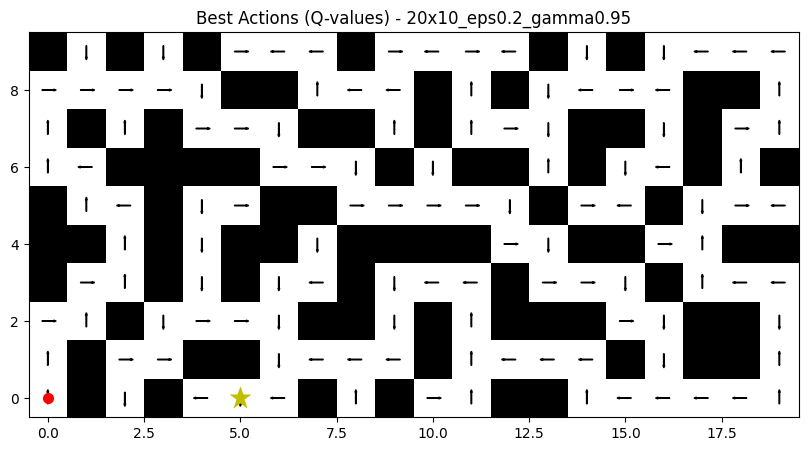


--- Route from start (0, 0) to treasure ---
✓ Route found in 53 steps


<Figure size 800x600 with 0 Axes>

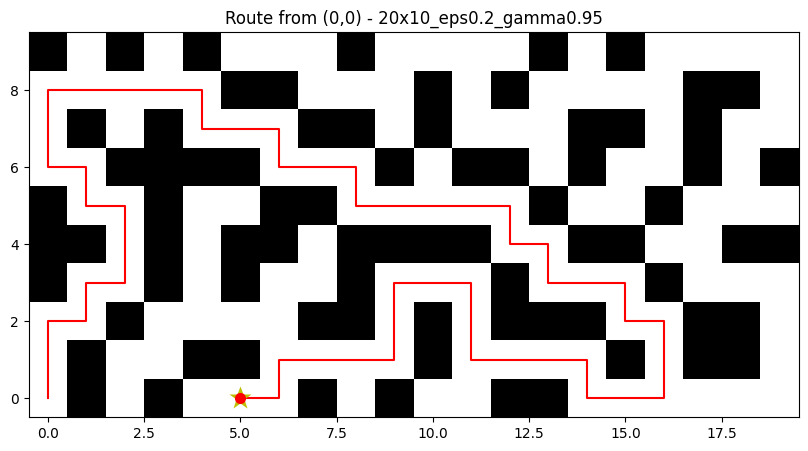


--- Route from alternative start (10, 5) to treasure ---
✓ Route found in 28 steps


<Figure size 800x600 with 0 Axes>

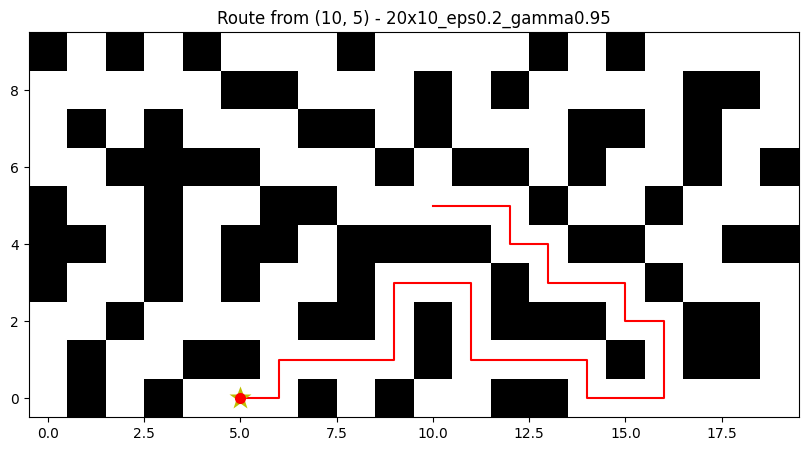


--- Route from alternative start (19, 0) to treasure ---
✗ No route found (stopped after 10000 steps)


In [12]:
# 20x10 maze with epsilon=0.2, gamma=0.95
env6, Q6, hist6 = run_experiment(20, 10, epsilon=0.2, gamma=0.95, epochs=500, experiment_name='20x10_eps0.2_gamma0.95')

## Experiments for 40x40 Maze


EXPERIMENT: 40x40_eps0.0_gamma0.9
Maze size: 40x40, epsilon: 0.0, gamma: 0.9, epochs: 1500

Treasure position: (18, 15)

Training...
Epoch 0: Finished in 203460 steps
Epoch 100: Finished in 1545 steps
Epoch 200: Finished in 869 steps
Epoch 300: Finished in 1005 steps
Epoch 400: Finished in 729 steps
Epoch 500: Finished in 617 steps
Epoch 600: Finished in 609 steps
Epoch 700: Finished in 367 steps
Epoch 800: Finished in 357 steps
Epoch 900: Finished in 345 steps
Epoch 1000: Finished in 339 steps
Epoch 1100: Finished in 339 steps
Epoch 1200: Finished in 339 steps
Epoch 1300: Finished in 339 steps
Epoch 1400: Finished in 339 steps
Training complete!



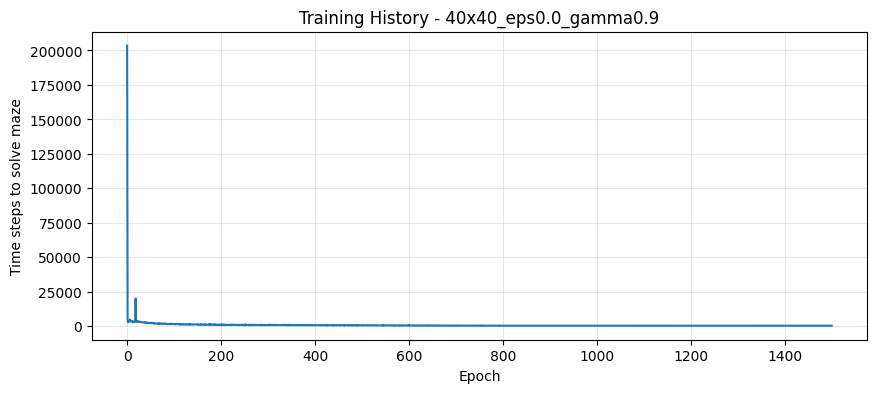

<Figure size 1200x1200 with 0 Axes>

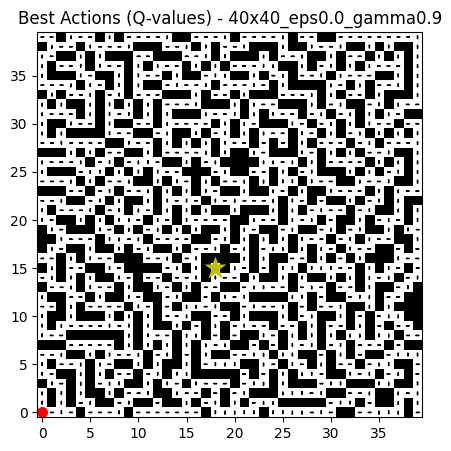


--- Route from start (0, 0) to treasure ---
✓ Route found in 339 steps


<Figure size 1200x1200 with 0 Axes>

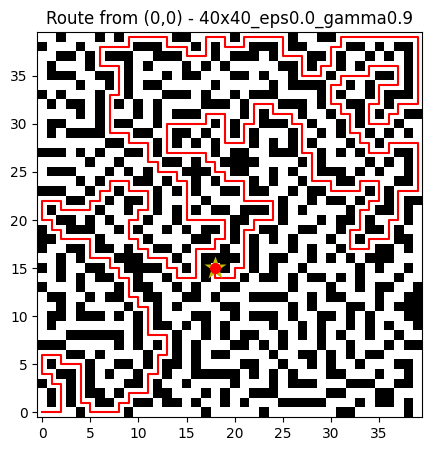


--- Route from alternative start (39, 0) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (0, 39) to treasure ---
✗ No route found (stopped after 10000 steps)


In [13]:
# 40x40 maze with epsilon=0, gamma=0.9
env7, Q7, hist7 = run_experiment(40, 40, epsilon=0.0, gamma=0.9, epochs=1500, experiment_name='40x40_eps0.0_gamma0.9')


EXPERIMENT: 40x40_eps0.0_gamma0.95
Maze size: 40x40, epsilon: 0.0, gamma: 0.95, epochs: 1500

Treasure position: (24, 5)

Training...
Epoch 0: Finished in 93086 steps
Epoch 100: Finished in 401 steps
Epoch 200: Finished in 285 steps
Epoch 300: Finished in 193 steps
Epoch 400: Finished in 155 steps
Epoch 500: Finished in 155 steps
Epoch 600: Finished in 155 steps
Epoch 700: Finished in 155 steps
Epoch 800: Finished in 155 steps
Epoch 900: Finished in 155 steps
Epoch 1000: Finished in 155 steps
Epoch 1100: Finished in 155 steps
Epoch 1200: Finished in 155 steps
Epoch 1300: Finished in 155 steps
Epoch 1400: Finished in 155 steps
Training complete!



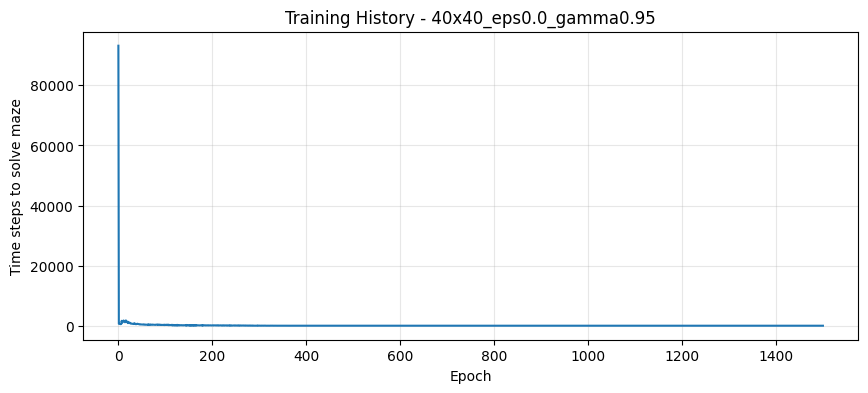

<Figure size 1200x1200 with 0 Axes>

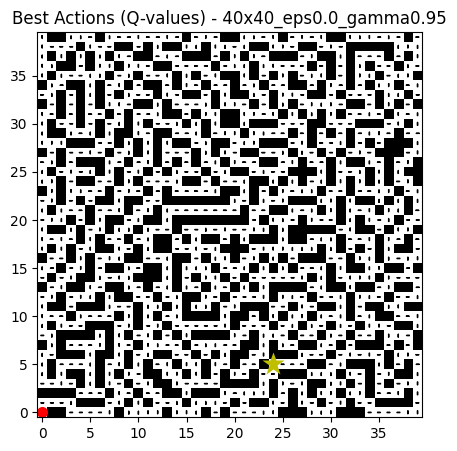


--- Route from start (0, 0) to treasure ---
✓ Route found in 155 steps


<Figure size 1200x1200 with 0 Axes>

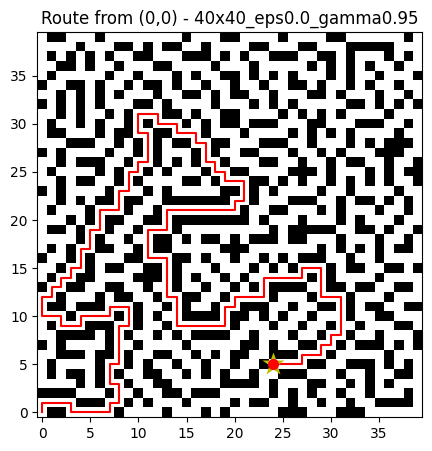


--- Route from alternative start (39, 0) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (0, 39) to treasure ---
✗ No route found (stopped after 10000 steps)


In [14]:
# 40x40 maze with epsilon=0, gamma=0.95
env8, Q8, hist8 = run_experiment(40, 40, epsilon=0.0, gamma=0.95, epochs=1500, experiment_name='40x40_eps0.0_gamma0.95')


EXPERIMENT: 40x40_eps0.1_gamma0.9
Maze size: 40x40, epsilon: 0.1, gamma: 0.9, epochs: 1500

Treasure position: (10, 5)

Training...
Epoch 0: Finished in 53601 steps
Epoch 100: Finished in 566 steps
Epoch 200: Finished in 409 steps
Epoch 300: Finished in 317 steps
Epoch 400: Finished in 291 steps
Epoch 500: Finished in 280 steps
Epoch 600: Finished in 228 steps
Epoch 700: Finished in 248 steps
Epoch 800: Finished in 239 steps
Epoch 900: Finished in 227 steps
Epoch 1000: Finished in 237 steps
Epoch 1100: Finished in 237 steps
Epoch 1200: Finished in 241 steps
Epoch 1300: Finished in 228 steps
Epoch 1400: Finished in 225 steps
Training complete!



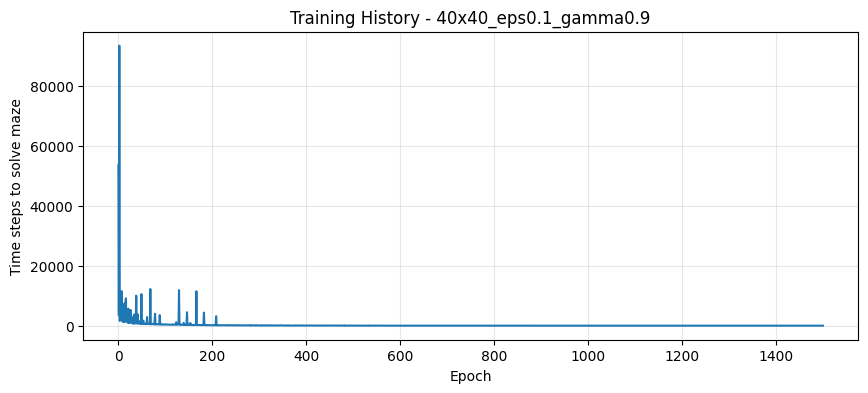

<Figure size 1200x1200 with 0 Axes>

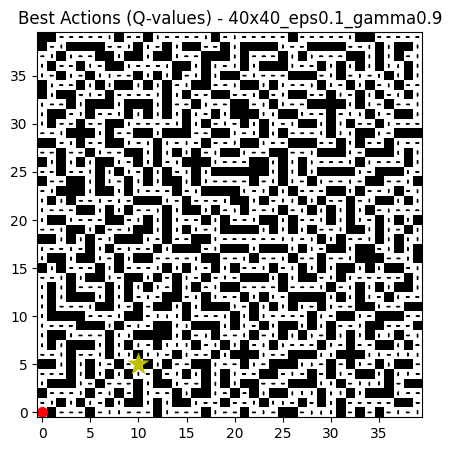


--- Route from start (0, 0) to treasure ---
✓ Route found in 211 steps


<Figure size 1200x1200 with 0 Axes>

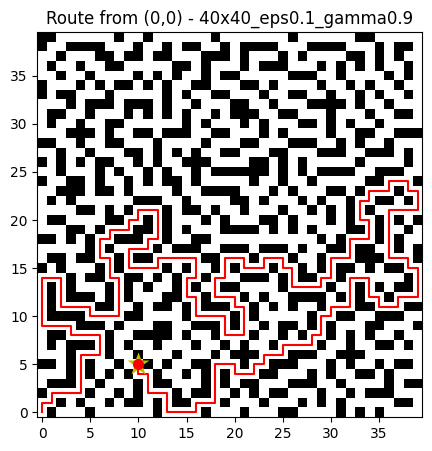


--- Route from alternative start (20, 20) to treasure ---
✗ No route found (stopped after 10000 steps)

--- Route from alternative start (39, 0) to treasure ---
✗ No route found (stopped after 10000 steps)


In [15]:
# 40x40 maze with epsilon=0.1, gamma=0.9
env9, Q9, hist9 = run_experiment(40, 40, epsilon=0.1, gamma=0.9, epochs=1500, experiment_name='40x40_eps0.1_gamma0.9')


EXPERIMENT: 40x40_eps0.1_gamma0.95
Maze size: 40x40, epsilon: 0.1, gamma: 0.95, epochs: 1500

Treasure position: (35, 6)

Training...
Epoch 0: Finished in 143728 steps
Epoch 100: Finished in 1986 steps
Epoch 200: Finished in 1687 steps
Epoch 300: Finished in 1299 steps
Epoch 400: Finished in 806 steps
Epoch 500: Finished in 820 steps
Epoch 600: Finished in 711 steps
Epoch 700: Finished in 554 steps
Epoch 800: Finished in 608 steps
Epoch 900: Finished in 539 steps
Epoch 1000: Finished in 452 steps
Epoch 1100: Finished in 441 steps
Epoch 1200: Finished in 422 steps
Epoch 1300: Finished in 448 steps
Epoch 1400: Finished in 437 steps
Training complete!



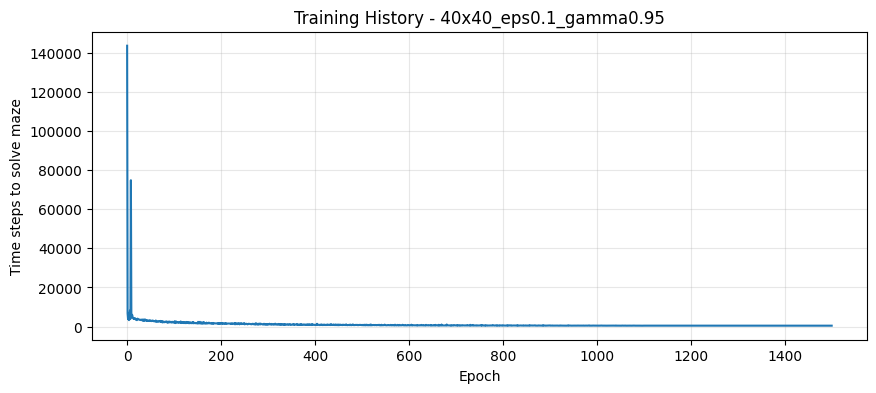

<Figure size 1200x1200 with 0 Axes>

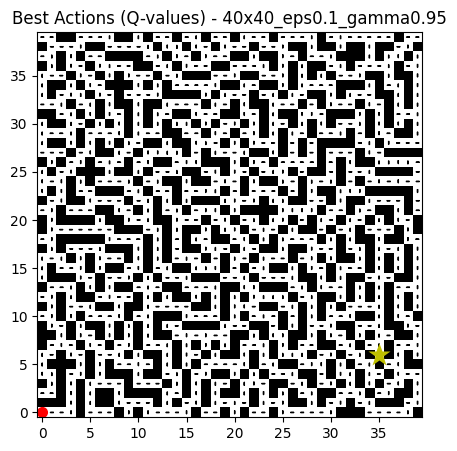


--- Route from start (0, 0) to treasure ---
✓ Route found in 389 steps


<Figure size 1200x1200 with 0 Axes>

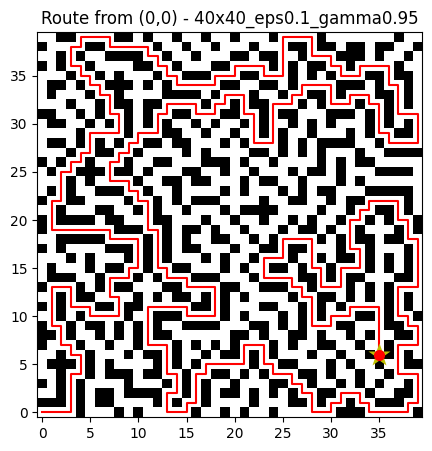


--- Route from alternative start (0, 39) to treasure ---
✗ No route found (stopped after 10000 steps)


In [16]:
# 40x40 maze with epsilon=0.1, gamma=0.95
env10, Q10, hist10 = run_experiment(40, 40, epsilon=0.1, gamma=0.95, epochs=1500, experiment_name='40x40_eps0.1_gamma0.95')


EXPERIMENT: 40x40_eps0.2_gamma0.9
Maze size: 40x40, epsilon: 0.2, gamma: 0.9, epochs: 1500

Treasure position: (24, 17)

Training...
Epoch 0: Finished in 137759 steps
Epoch 100: Finished in 2708 steps
Epoch 200: Finished in 1858 steps
Epoch 300: Finished in 2159 steps
Epoch 400: Finished in 1148 steps
Epoch 500: Finished in 1077 steps
Epoch 600: Finished in 904 steps
Epoch 700: Finished in 841 steps
Epoch 800: Finished in 724 steps
Epoch 900: Finished in 607 steps
Epoch 1000: Finished in 635 steps
Epoch 1100: Finished in 570 steps
Epoch 1200: Finished in 606 steps
Epoch 1300: Finished in 584 steps
Epoch 1400: Finished in 557 steps
Training complete!



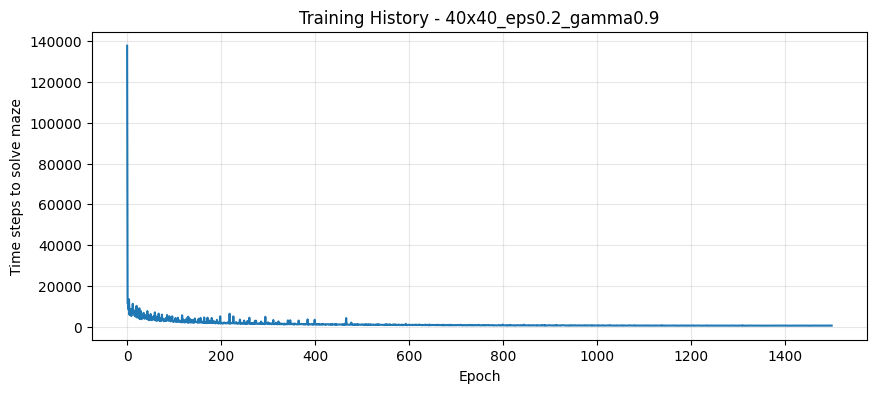

<Figure size 1200x1200 with 0 Axes>

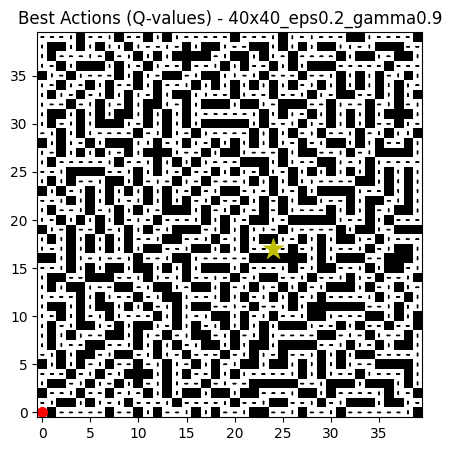


--- Route from start (0, 0) to treasure ---
✓ Route found in 441 steps


<Figure size 1200x1200 with 0 Axes>

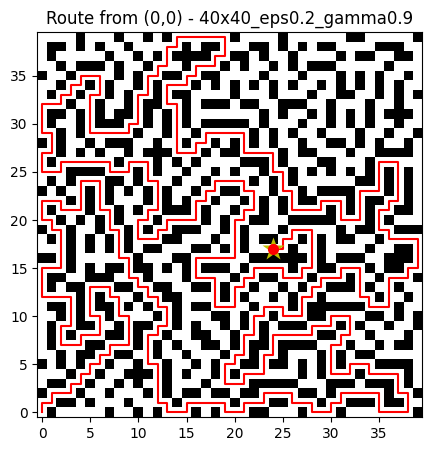


--- Route from alternative start (20, 20) to treasure ---
✓ Route found in 41 steps


<Figure size 1200x1200 with 0 Axes>

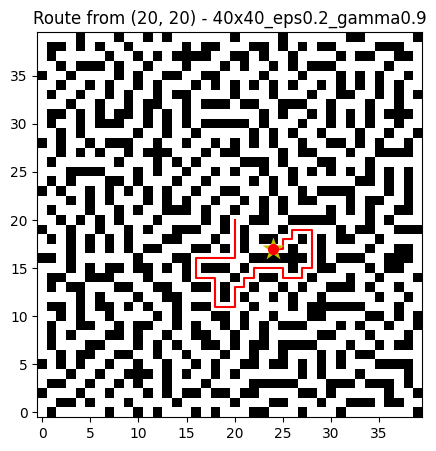


--- Route from alternative start (0, 39) to treasure ---
✗ No route found (stopped after 10000 steps)


In [17]:
# 40x40 maze with epsilon=0.2, gamma=0.9
env11, Q11, hist11 = run_experiment(40, 40, epsilon=0.2, gamma=0.9, epochs=1500, experiment_name='40x40_eps0.2_gamma0.9')


EXPERIMENT: 40x40_eps0.2_gamma0.95
Maze size: 40x40, epsilon: 0.2, gamma: 0.95, epochs: 1500

Treasure position: (16, 39)

Training...
Epoch 0: Finished in 69051 steps
Epoch 100: Finished in 1331 steps
Epoch 200: Finished in 806 steps
Epoch 300: Finished in 564 steps
Epoch 400: Finished in 477 steps
Epoch 500: Finished in 419 steps
Epoch 600: Finished in 417 steps
Epoch 700: Finished in 390 steps
Epoch 800: Finished in 367 steps
Epoch 900: Finished in 367 steps
Epoch 1000: Finished in 343 steps
Epoch 1100: Finished in 353 steps
Epoch 1200: Finished in 363 steps
Epoch 1300: Finished in 361 steps
Epoch 1400: Finished in 351 steps
Training complete!



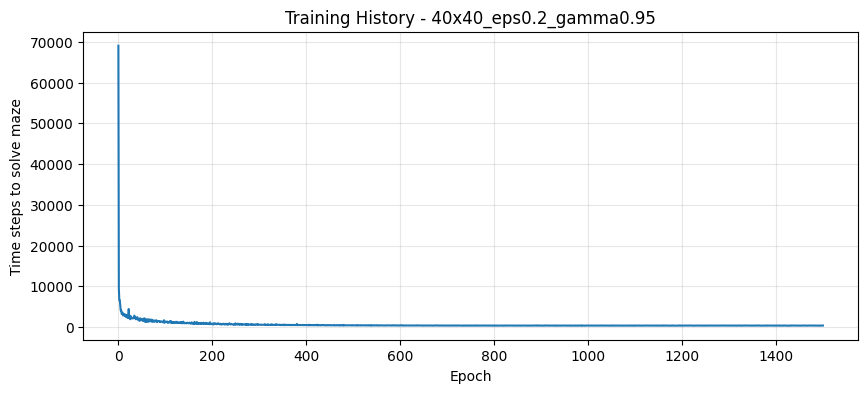

<Figure size 1200x1200 with 0 Axes>

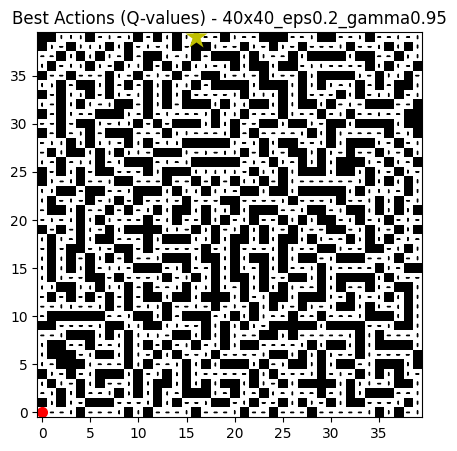


--- Route from start (0, 0) to treasure ---
✓ Route found in 287 steps


<Figure size 1200x1200 with 0 Axes>

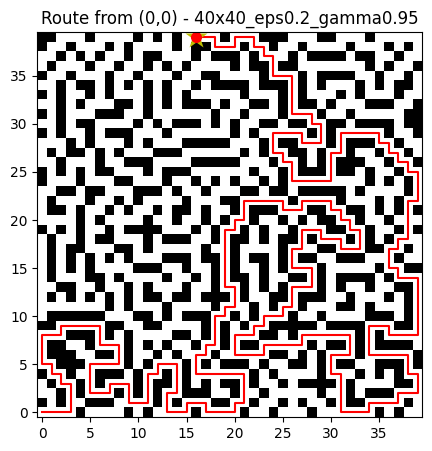


--- Route from alternative start (20, 20) to treasure ---
✓ Route found in 191 steps


<Figure size 1200x1200 with 0 Axes>

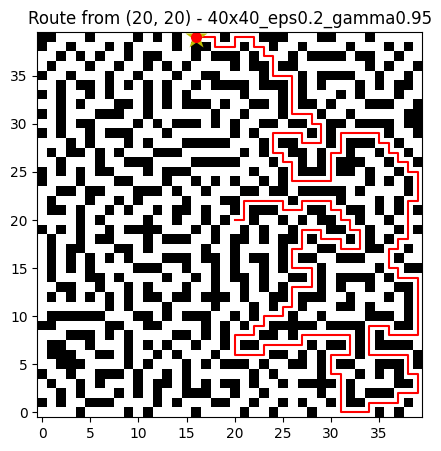


--- Route from alternative start (39, 0) to treasure ---
✓ Route found in 104 steps


<Figure size 1200x1200 with 0 Axes>

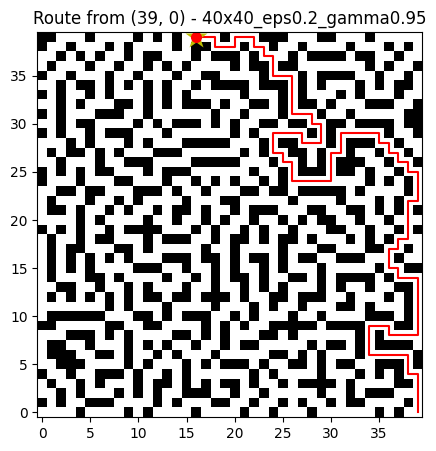

In [18]:
# 40x40 maze with epsilon=0.2, gamma=0.95
env12, Q12, hist12 = run_experiment(40, 40, epsilon=0.2, gamma=0.95, epochs=1500, experiment_name='40x40_eps0.2_gamma0.95')

## Analysis Summary

In [19]:
print("\n" + "="*80)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*80)
print("\n### Effect of epsilon (exploration rate):")
print("- epsilon = 0: Pure exploitation (greedy) - may get stuck in local optima")
print("- epsilon > 0: Allows exploration - helps discover better paths")
print("\n### Effect of gamma (discount factor):")
print("- gamma = 0.9: Less weight on future rewards")
print("- gamma = 0.95: More weight on future rewards - better for long-term planning")
print("\n### Maze size observations:")
print("- 20x10: Smaller maze, converges faster")
print("- 40x40: Larger maze, requires more epochs and careful parameter tuning")
print("="*80)


SUMMARY OF ALL EXPERIMENTS

### Effect of epsilon (exploration rate):
- epsilon = 0: Pure exploitation (greedy) - may get stuck in local optima
- epsilon > 0: Allows exploration - helps discover better paths

### Effect of gamma (discount factor):
- gamma = 0.9: Less weight on future rewards
- gamma = 0.95: More weight on future rewards - better for long-term planning

### Maze size observations:
- 20x10: Smaller maze, converges faster
- 40x40: Larger maze, requires more epochs and careful parameter tuning
